# Question 1
Data Distribution

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import multivariate_normal
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split, KFold
from sklearn.metrics import log_loss
from kneed import KneeLocator

In [3]:
# Define parameters

m1 = np.array([1, 1, 1])
m2 = np.array([-1, -1, -1])
m3 = np.array([-1, 1, 1])
m4 = np.array([1, -1, -1])

means = np.array([m1, m2, m3, m4])
cov = np.eye(3)*0.75

In [ ]:
'''
# Generate sampels
for n in [100, 500, 1000, 5000, 10000, 100000]:
    labels = np.random.choice([1, 2, 3, 4], n)

    # generate random samples with the given label and save it in a dataframe
    samples = pd.DataFrame(columns = ['labels', 'X1', 'X2', 'X3'])
    samples['labels'] = labels

    for i in range(n):
        if labels[i] == 1:
            samples.iloc[i, 1:] = np.random.multivariate_normal(m1, cov)
        elif labels[i] == 2:
            samples.iloc[i, 1:] = np.random.multivariate_normal(m2, cov)
        elif labels[i] == 3:
            samples.iloc[i, 1:] = np.random.multivariate_normal(m3, cov)
        else:
            samples.iloc[i, 1:] = np.random.multivariate_normal(m4, cov)

    # save the samples with labels as csv
    samples.to_csv(f'samples{n}.csv', index=False)
'''
train100 = pd.read_csv('samples100.csv')
train500 = pd.read_csv('samples500.csv')
train1000 = pd.read_csv('samples1000.csv')
train5000 = pd.read_csv('samples5000.csv')
train10000 = pd.read_csv('samples10000.csv')
validation = pd.read_csv('samples100000.csv')
dataset = [train100, train500, train1000, train5000, train10000, validation]

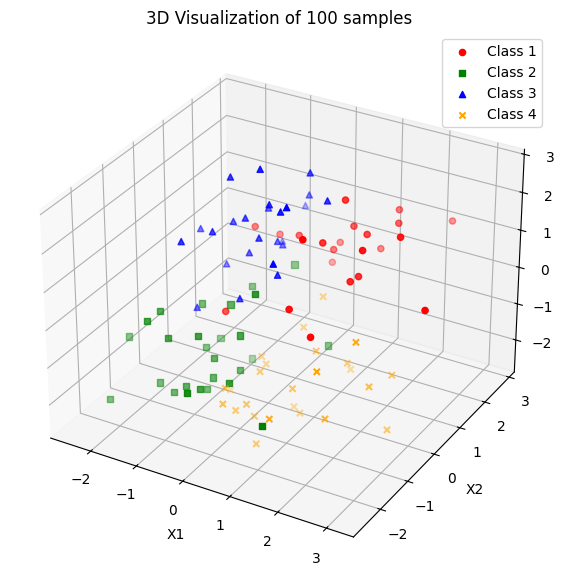

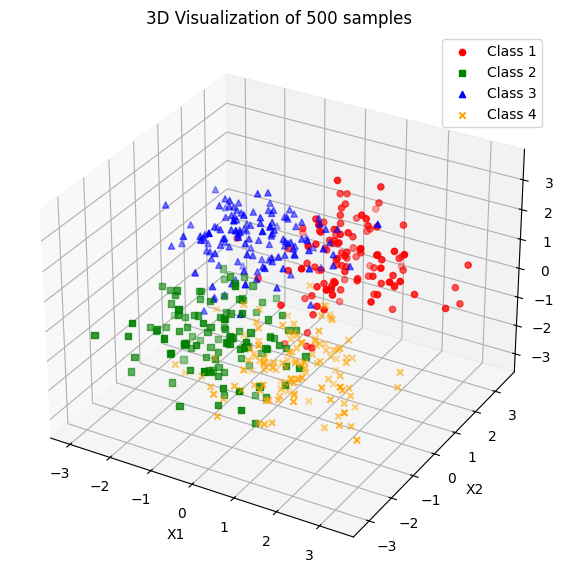

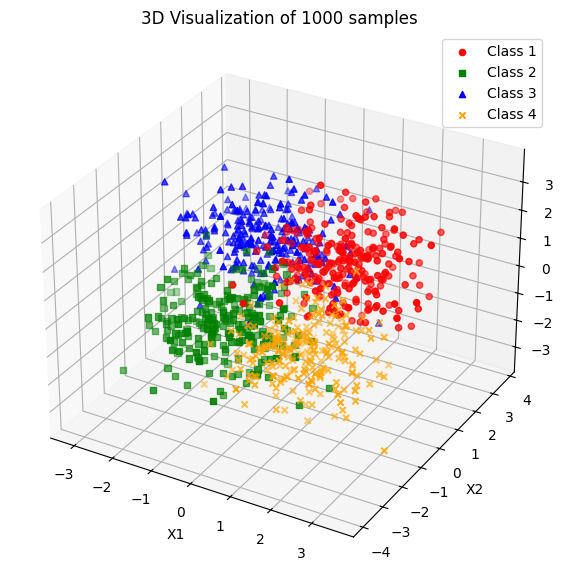

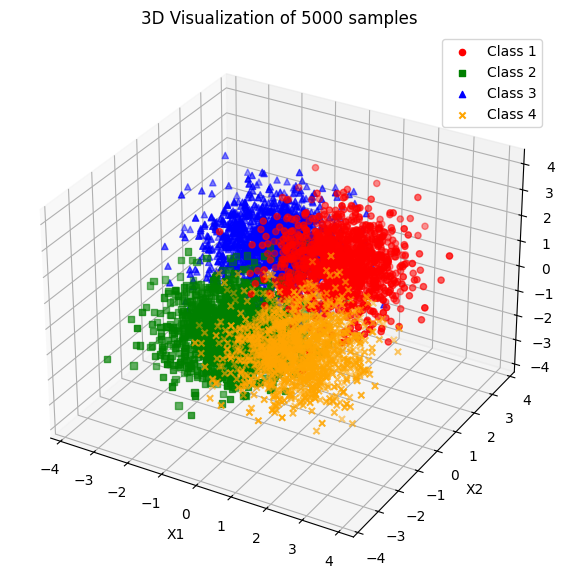

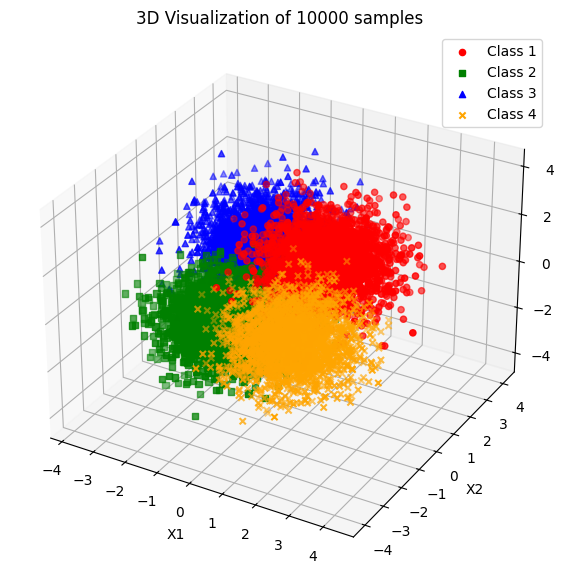

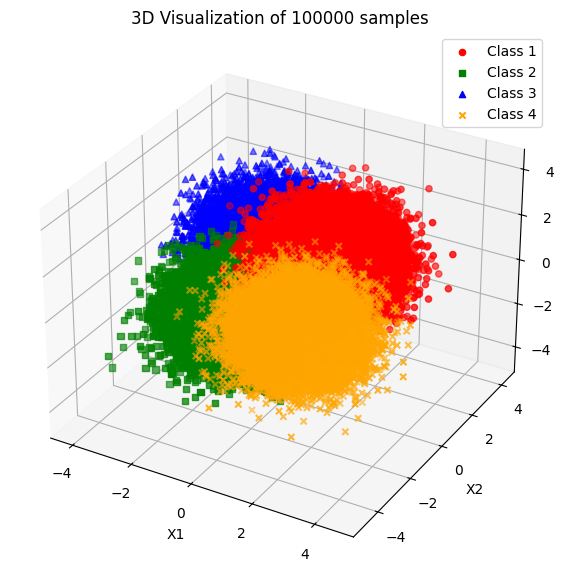

In [5]:

# Create a function for 3D scatter plot 
def plot3D(samples):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot, color by ytrain values (classes or labels)
    scatter1 = ax.scatter(samples[samples.labels == 1].iloc[:, 1], samples[samples.labels == 1].iloc[:, 2], samples[samples.labels == 1].iloc[:, 3], 
                        c='red', marker='o', label = 'Class 1')
    scatter2 = ax.scatter(samples[samples.labels == 2].iloc[:, 1], samples[samples.labels == 2].iloc[:, 2], samples[samples.labels == 2].iloc[:, 3], 
                        c='green', marker='s', label = 'Class 2')
    scatter3 = ax.scatter(samples[samples.labels == 3].iloc[:, 1], samples[samples.labels == 3].iloc[:, 2], samples[samples.labels == 3].iloc[:, 3], 
                        c='blue', marker='^', label = 'Class 3')
    scatter4 = ax.scatter(samples[samples.labels == 4].iloc[:, 1], samples[samples.labels == 4].iloc[:, 2], samples[samples.labels == 4].iloc[:, 3], 
                        c='orange', marker='x', label = 'Class 4')

    # Add labels and title
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title(f'3D Visualization of {len(samples)} samples')

    plt.legend()
    plt.show()

for sample in dataset:
    plot3D(sample)

In [6]:
def map_classifier(X, means, covariances, priors=[0.25]*4):
    posteriors = []
    for i in range(4):
        likelihood = multivariate_normal.pdf(X, mean=means[i], cov=covariances)
        posteriors.append(likelihood * priors[i])
    posteriors = np.array(posteriors).T
    return np.argmax(posteriors, axis=1)+1

# Calculate the theoretically optimal classifier's accuracy on the test set
for sample in dataset:
    Xtrain = np.array(sample.iloc[:, 1:])
    ytrain = np.array(sample.labels)
    y_pred_map = map_classifier(Xtrain, means, cov)
    map_error = np.mean(ytrain != y_pred_map)
    print(f"Theoretical MAP classifier error of {len(sample)} training set: {map_error:.4f}")

Theoretical MAP classifier error of 100 training set: 0.1900
Theoretical MAP classifier error of 500 training set: 0.1520
Theoretical MAP classifier error of 1000 training set: 0.1660
Theoretical MAP classifier error of 5000 training set: 0.1602
Theoretical MAP classifier error of 10000 training set: 0.1570
Theoretical MAP classifier error of 100000 training set: 0.1559


Knowing that the priors are uniform, Theoretical optimal classifer results in the same error as the MAP classifer. Yet, it is re-classifed.

In [7]:
def bayes_classifier(X, means, covariances):
    prob = []
    for i in range(4):
        likelihood = multivariate_normal.pdf(X, mean=means[i], cov=covariances)
        prob.append(likelihood)
    prob = np.array(prob).T
    return np.argmax(prob, axis=1)+1

# Calculate the theoretically optimal classifier's accuracy on the test set
for sample in dataset:
    Xtrain = np.array(sample.iloc[:, 1:])
    ytrain = np.array(sample.labels)
    y_pred_bayes = bayes_classifier(Xtrain, means, cov)
    bayes_error = np.mean(ytrain != y_pred_bayes)
    print(f"Theoretical Optimal classifier error of {len(sample)} training set: {bayes_error:.4f}")

Theoretical Optimal classifier error of 100 training set: 0.1900
Theoretical Optimal classifier error of 500 training set: 0.1520
Theoretical Optimal classifier error of 1000 training set: 0.1660
Theoretical Optimal classifier error of 5000 training set: 0.1602
Theoretical Optimal classifier error of 10000 training set: 0.1570
Theoretical Optimal classifier error of 100000 training set: 0.1559


Multi-Layer Perceptron

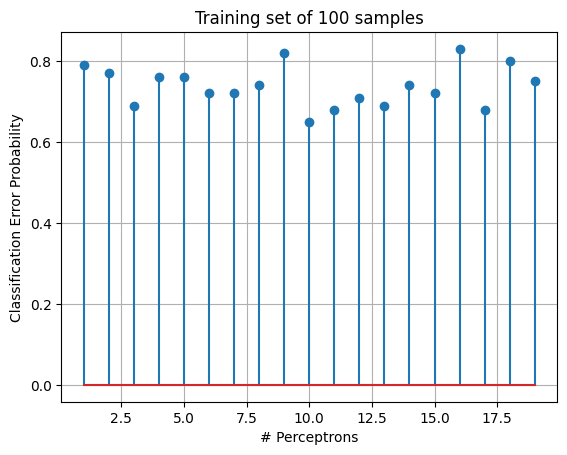

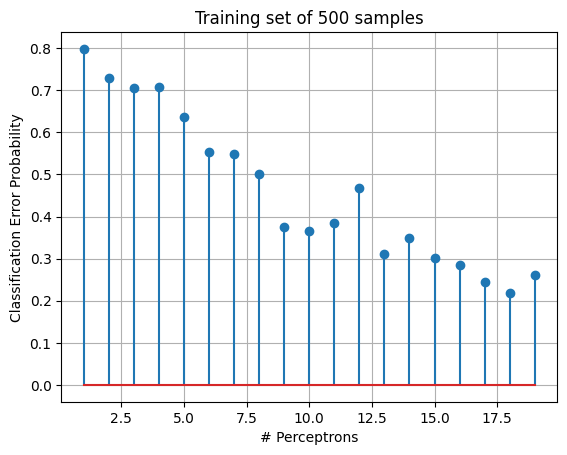

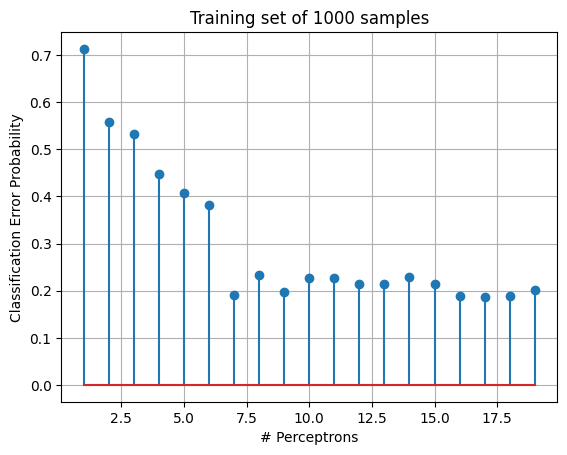

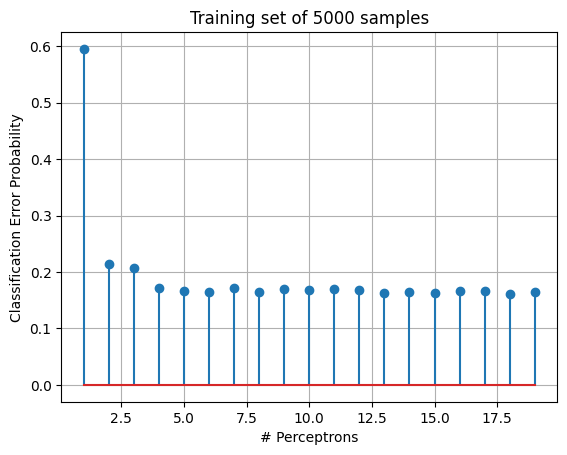

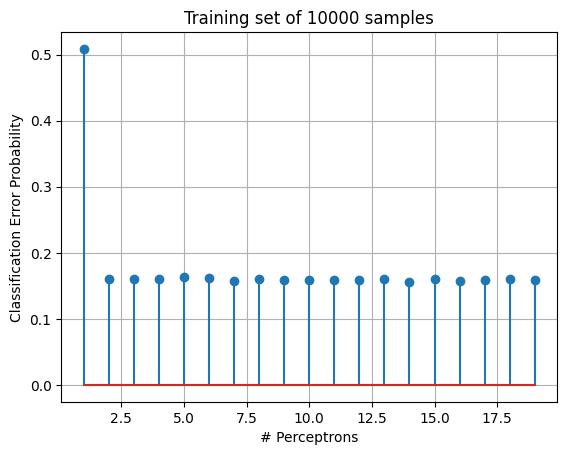

[10, 18, 17, 18, 14] [0.65, 0.21800000000000008, 0.18700000000000006, 0.16159999999999997, 0.15589999999999993]


In [8]:
# This takes five minutes to run

perceptrons_range = range(1, 20)
errors = []
best_perceptrons = []
for data in dataset[:-1]:

    Xtrain = np.array(data[['X1', 'X2', 'X3']])
    ytrain = np.array(data.labels)

    # Cross-validation
    kf = KFold(n_splits=10)
    scores = []
    for n_perceptrons in perceptrons_range:
        model = MLPClassifier(hidden_layer_sizes=(n_perceptrons,), activation='tanh', max_iter=10000, early_stopping=True)
        score = cross_val_score(model, Xtrain, ytrain, cv=kf)
        scores.append(np.mean(score))
    plt.stem(perceptrons_range, 1-np.array(scores), label='Error')
    plt.grid(True, which='both')
    plt.title(f'Training set of {len(data)} samples')
    plt.xlabel('# Perceptrons')
    plt.ylabel('Classification Error Probability')
    plt.show()

    best_perceptrons.append(perceptrons_range[np.argmax(scores)])
    errors.append(1-np.max(scores))

print(best_perceptrons, errors)


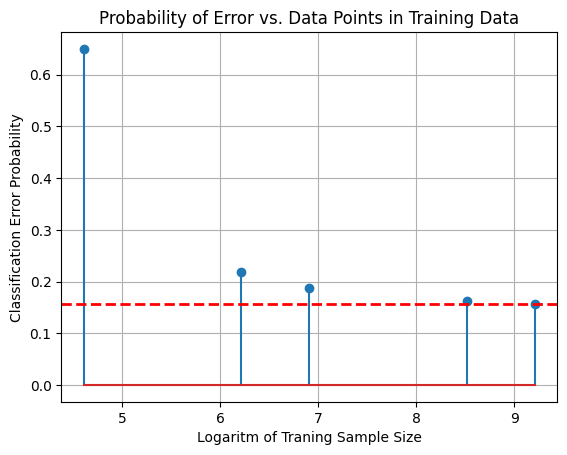

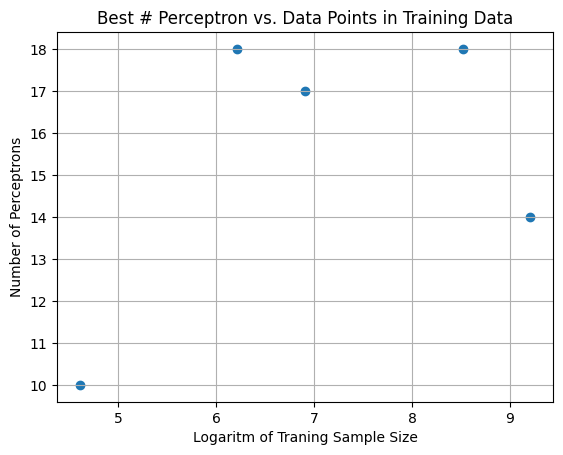

In [9]:
sizes = [100, 500, 1000, 5000, 10000]
plt.stem(np.log(sizes), errors, label='Error')
plt.grid(True, which='both')
plt.title('Probability of Error vs. Data Points in Training Data')
plt.axhline(y=np.min(errors), color='r', linestyle='--', linewidth=2)
plt.xlabel('Logaritm of Traning Sample Size')
plt.ylabel('Classification Error Probability')
plt.show()

plt.scatter(np.log(sizes), best_perceptrons, label='Perceptron')
plt.grid(True, which='both')
plt.title('Best # Perceptron vs. Data Points in Training Data')
plt.xlabel('Logaritm of Traning Sample Size')
plt.ylabel('Number of Perceptrons')
plt.show()



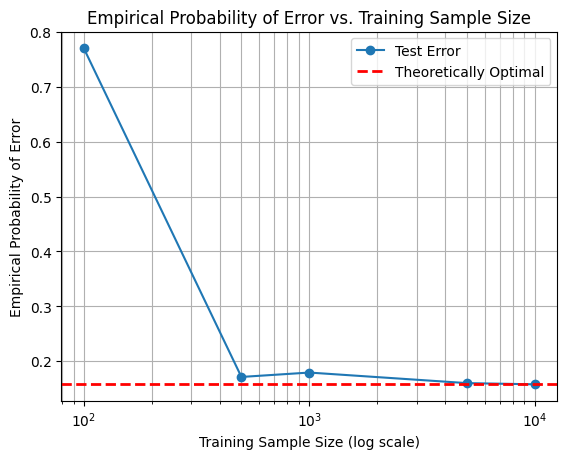

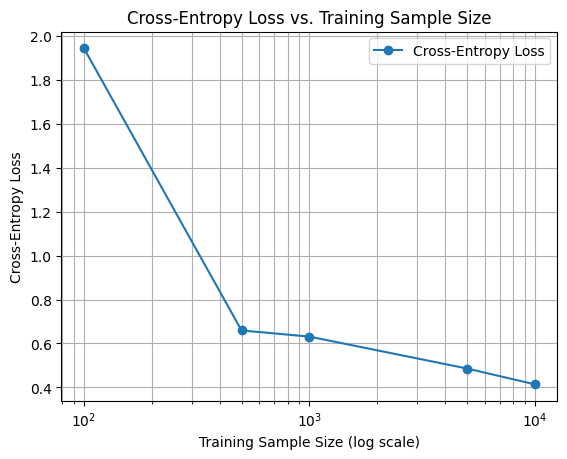

Training size: 100, Best Perceptrons: 13, Empirical Test Error: 0.77049, Cross-Entropy Loss: 1.9426944624947131
Training size: 500, Best Perceptrons: 19, Empirical Test Error: 0.17125, Cross-Entropy Loss: 0.6593118967281444
Training size: 1000, Best Perceptrons: 15, Empirical Test Error: 0.17925999999999997, Cross-Entropy Loss: 0.6312423901073593
Training size: 5000, Best Perceptrons: 18, Empirical Test Error: 0.16000000000000003, Cross-Entropy Loss: 0.48616220550971223
Training size: 10000, Best Perceptrons: 17, Empirical Test Error: 0.15780000000000005, Cross-Entropy Loss: 0.41420843153867637


In [ ]:

# Set up validation data
X_val = np.array(validation[['X1', 'X2', 'X3']])
y_val = np.array(validation.labels)

# Store test set error probabilities and cross-entropy values
test_errors = []
cross_entropy_values = []

# Loop through each dataset size, train with best perceptron count, and evaluate on validation set
for i, data in enumerate(dataset[:-1]):
    X_train = np.array(data[['X1', 'X2', 'X3']])
    y_train = np.array(data.labels)
    
    # Train with the best number of perceptrons found for this training size
    n_perceptrons = best_perceptrons[i]
    model = MLPClassifier(hidden_layer_sizes=(n_perceptrons,), activation='tanh', max_iter=10000, early_stopping=True, solver='sgd') # sgd solver uses cross entropy loss minimization with stochastic gradient descent
    model.fit(X_train, y_train)
    
    # Predict probabilities on the validation set for cross-entropy calculation
    y_proba = model.predict_proba(X_val)
    
    # Calculate the empirical probability of error on the validation set
    y_pred = model.predict(X_val)
    error = 1 - accuracy_score(y_val, y_pred)
    test_errors.append(error)
    
    # Calculate cross-entropy loss on the validation set
    ce_loss = log_loss(y_val, y_proba)
    cross_entropy_values.append(ce_loss)

# Plot the test error probabilities on a semi-log scale
plt.figure()
plt.semilogx(sizes, test_errors, marker='o', linestyle='-', label='Test Error')
plt.axhline(y=np.min(test_errors), color='r', linestyle='--', linewidth=2, label='Theoretically Optimal')
plt.xlabel('Training Sample Size (log scale)')
plt.ylabel('Empirical Probability of Error')
plt.title('Empirical Probability of Error vs. Training Sample Size')
plt.legend()
plt.grid(True, which='both')
plt.show()

# Plot cross-entropy loss for each model
plt.figure()
plt.semilogx(sizes, cross_entropy_values, marker='o', linestyle='-', label='Cross-Entropy Loss')
plt.xlabel('Training Sample Size (log scale)')
plt.ylabel('Cross-Entropy Loss')
plt.title('Cross-Entropy Loss vs. Training Sample Size')
plt.legend()
plt.grid(True, which='both')
plt.show()

# Reporting and documenting steps
for i, size in enumerate(sizes):
    print(f"Training size: {size}, Best Perceptrons: {best_perceptrons[i]}, Empirical Test Error: {test_errors[i]}, Cross-Entropy Loss: {cross_entropy_values[i]}")


# Question 2

C:\Users\tabat\AppData\Local\Temp\ipykernel_27416\43041004.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


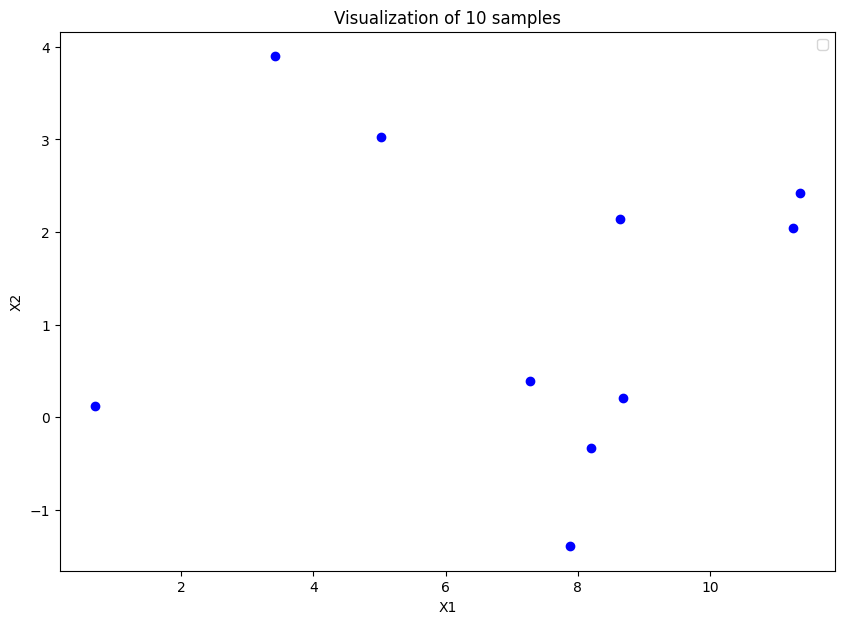

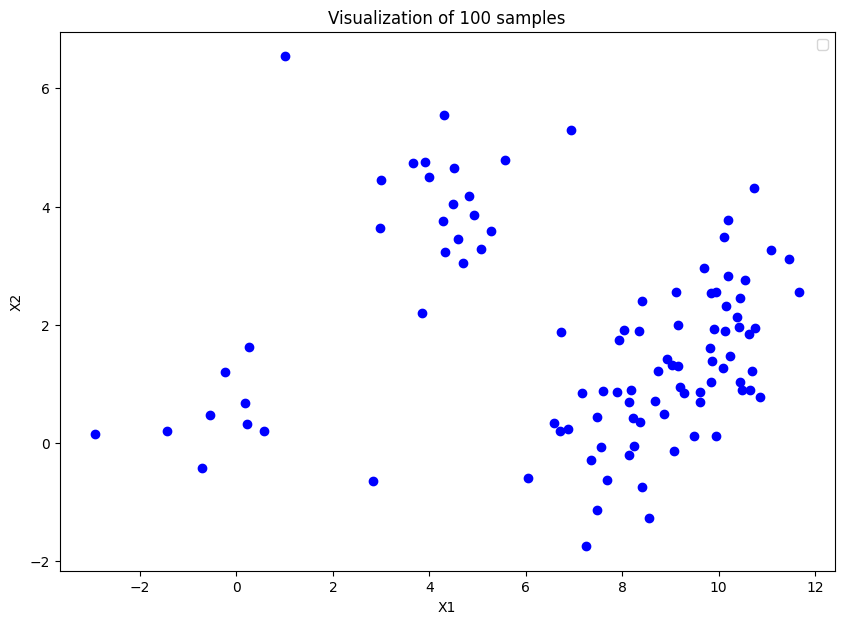

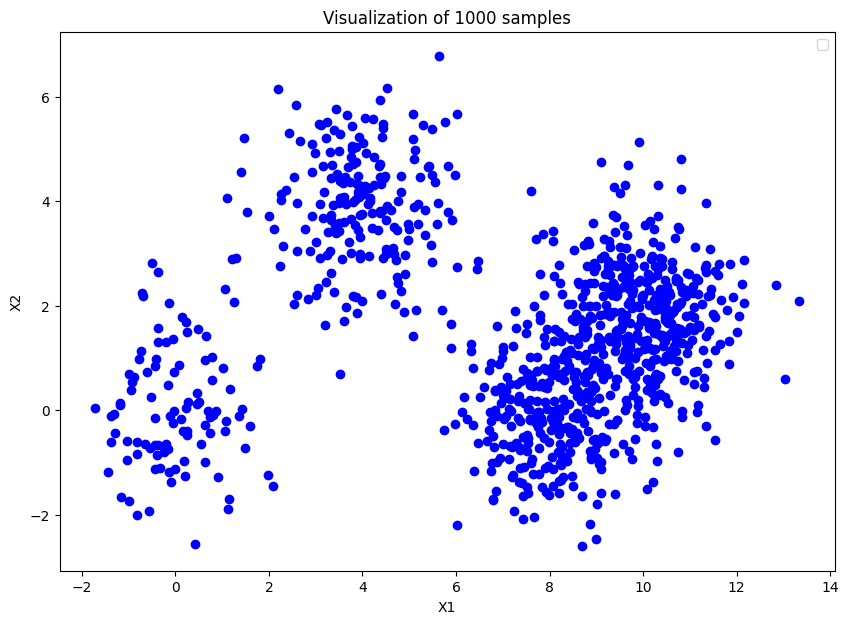

In [67]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

# Step 1: Define the true GMM parameters
true_means = [np.array([0, 0]), np.array([4, 4]), np.array([8, 0]), np.array([10, 2])]
true_covariances = [np.array([[1, 0], [0, 1]]), np.array([[1, 0], [0, 1]]),
                    np.array([[1, 0], [0, 1]]), np.array([[1, 0], [0, 1]])]
true_weights = [0.1, 0.2, 0.3, 0.4]

# Generate data from the true GMM
def generate_data(n_samples):
    data = []
    for mean, cov, weight in zip(true_means, true_covariances, true_weights):
        n_component_samples = int(n_samples * weight)
        component_data = np.random.multivariate_normal(mean, cov, n_component_samples)
        data.append(component_data)
    return np.vstack(data)

# Step 2: Generate datasets with different sample sizes
datasets = [generate_data(n) for n in [10, 100, 1000]]

# Create a function for 2D scatter plot 
def plot2d(samples):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111)

    # Scatter plot, color by ytrain values (classes or labels)
    scatter1 = ax.scatter(samples[:, 0], samples[:, 1], 
                        c='blue', marker='o')

    # Add labels and title
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_title(f'Visualization of {len(samples)} samples')

    plt.legend()
    plt.show()

for sample in datasets:
    plot2d(sample)


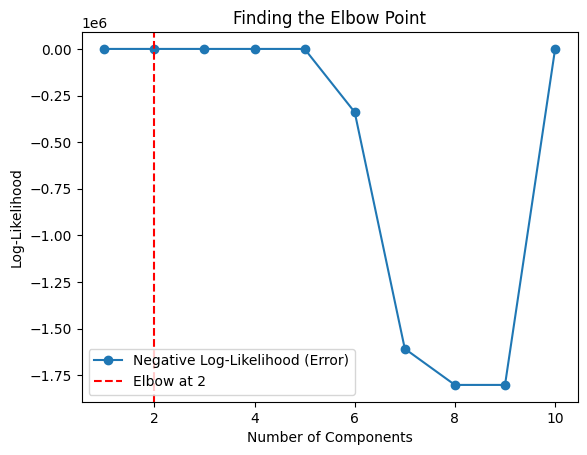

The elbow point of 10 samples is at 2 components.


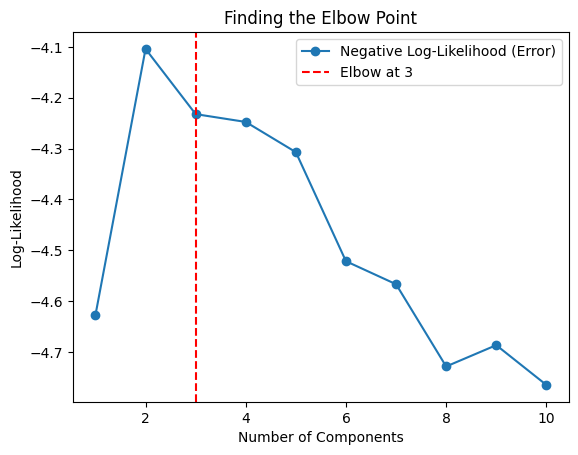

The elbow point of 100 samples is at 3 components.


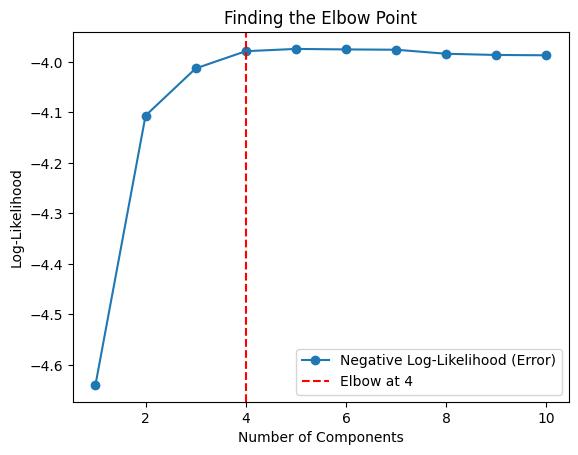

The elbow point of 1000 samples is at 4 components.


In [68]:
def cross_val_log_likelihood(X, n_components, n_splits=10):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    log_likelihoods = []

    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
        gmm.fit(X_train)
        log_likelihoods.append(gmm.score(X_test))

    return np.mean(log_likelihoods)

# Test multiple model orders for each dataset size
results = np.zeros((10, 3))
for n in range(len(datasets)):
    for n_components in range(1, 11):
        n_components = min(n_components, int(0.9*len(datasets[n])))
        avg_log_likelihood = cross_val_log_likelihood(datasets[n], n_components)
        results[n_components-1, n] = avg_log_likelihood


def optimal_component(log_likelihoods, size, components=range(1, 11)):
    kneedle = KneeLocator(components, log_likelihoods, curve="concave", direction="increasing")
    elbow_index = kneedle.elbow

    # Plot to visualize
    plt.plot(components, log_likelihoods, marker='o', label='Negative Log-Likelihood (Error)')
    plt.axvline(x=components[elbow_index], color='r', linestyle='--', label=f'Elbow at {components[elbow_index]}')
    plt.xlabel("Number of Components")
    plt.ylabel("Log-Likelihood")
    plt.title("Finding the Elbow Point")
    plt.legend()
    plt.show()
    print(f"The elbow point of {size} samples is at {components[elbow_index]} components.")

for i in range(3):
    s = len(datasets[i])
    loglike = results[:, i]
    optimal_component(loglike, s)


In [61]:
def find_optimal_component(log_likelihoods, components=range(1, 11)):
    kneedle = KneeLocator(components, log_likelihoods, curve="concave", direction="increasing")
    elbow_point = kneedle.elbow
    return elbow_point

def repetition(rep):
    frequency = np.zeros((10, 3))
    for i in range(rep):
        datasets = [generate_data(n) for n in [10, 100, 1000]]
        results = np.zeros((10, 3))
        for n in range(len(datasets)):
            for n_components in range(1, 11):
                n_components = min(n_components, int(0.9*len(datasets[n])))
                avg_log_likelihood = cross_val_log_likelihood(datasets[n], n_components)
                results[n_components-1, n] = avg_log_likelihood
            ans = find_optimal_component(results[:, n])
            frequency[ans-1, n] += 1
    return frequency

feq = repetition(100)

    

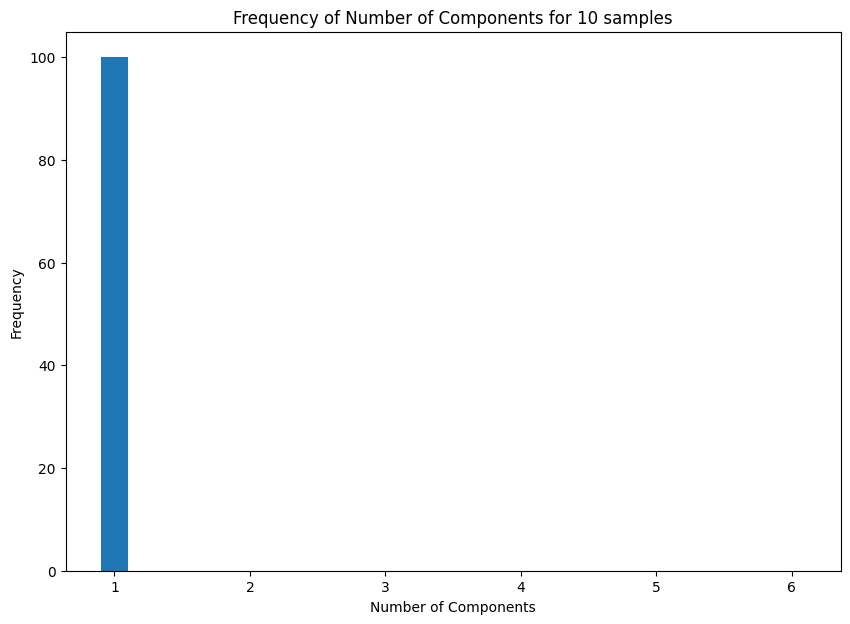

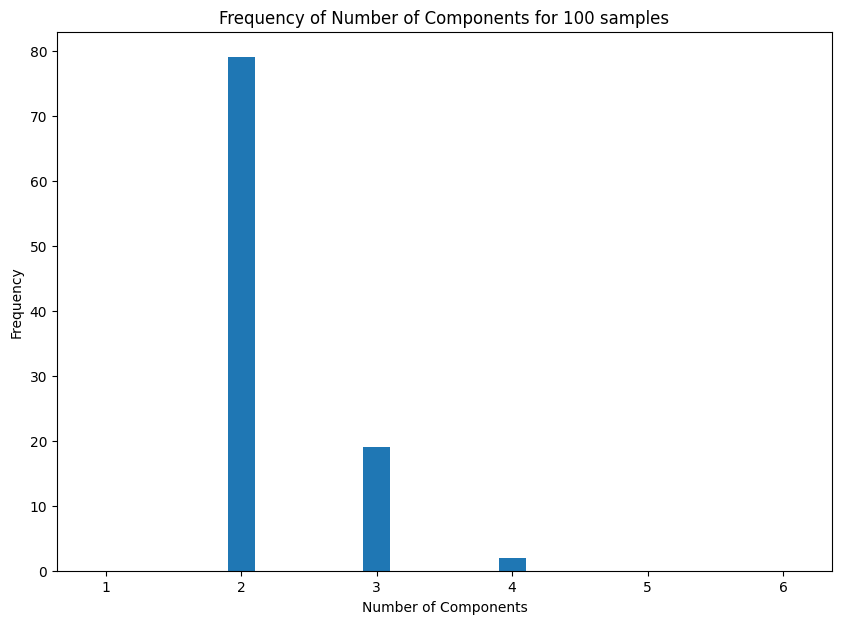

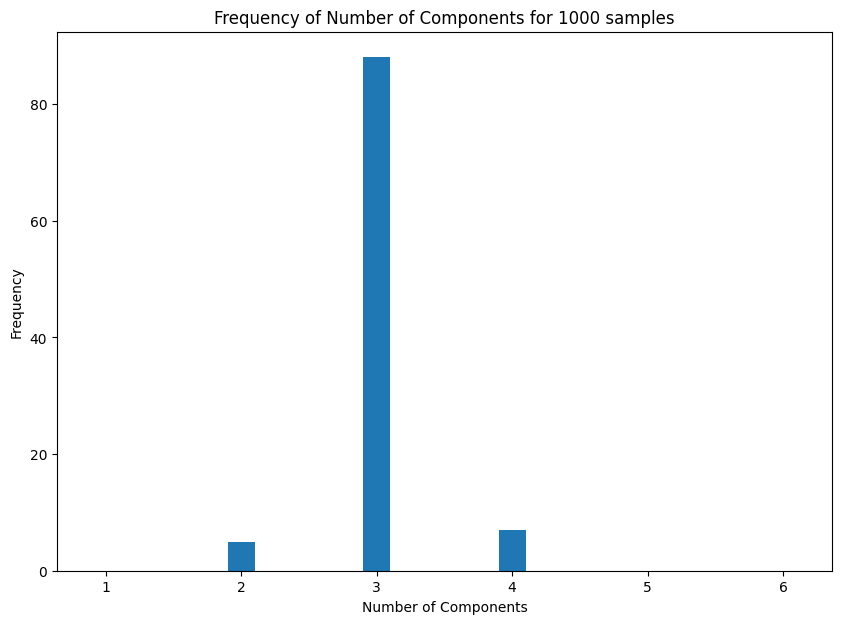

In [65]:
for i in range(3):
    fig, ax = plt.subplots(figsize=(10, 7))
    plt.bar(range(1, 7), feq[:6, i], 0.2)
    # Add labels and title
    ax.set_xlabel('Number of Components')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Frequency of Number of Components for {len(datasets[i])} samples')
    plt.show()

In [66]:
feq

array([[100.,   0.,   0.],
       [  0.,  79.,   5.],
       [  0.,  19.,  88.],
       [  0.,   2.,   7.],
       [  0.,   0.,   0.],
       [  0.,   0.,   0.],
       [  0.,   0.,   0.],
       [  0.,   0.,   0.],
       [  0.,   0.,   0.],
       [  0.,   0.,   0.]])